<a href="https://colab.research.google.com/github/pradhapmoorthi/CVND/blob/Trial/3_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# copy the vocab.pkl from "/content/gdrive/MyDrive/checkpoints"

# Computer Vision Nanodegree

## Project: Image Captioning

---

In this notebook, you will use your trained model to generate captions for images in the test dataset.

This notebook **will be graded**.  

Feel free to use the links below to navigate the notebook:
- [Step 1](#step1): Get Data Loader for Test Dataset
- [Step 2](#step2): Load Trained Models
- [Step 3](#step3): Finish the Sampler
- [Step 4](#step4): Clean up Captions
- [Step 5](#step5): Generate Predictions!

<a id='step1'></a>
## Step 1: Get Data Loader for Test Dataset

Before running the code cell below, define the transform in `transform_test` that you would like to use to pre-process the test images.  

Make sure that the transform that you define here agrees with the transform that you used to pre-process the training images (in **2_Training.ipynb**).  For instance, if you normalized the training images, you should also apply the same normalization procedure to the test images.

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [3]:
import os
from google.colab import drive

PROJECT_DIR = "/content/CVND"    # where model.py, data_loader.py, vocabulary.py live
COCOAPI_LOC = "/content"         # parent of /content/cocoapi/ — do not change
VOCAB_FILE  = "/content/drive/MyDrive/cvnd_coco/vocab.pkl"

# Prefer ckpt_best.pt because it is saved whenever BLEU-4 improves during
# training, making it the highest-quality checkpoint across the entire run.
# Fall back to a specific epoch checkpoint if the best file doesn't exist yet
# (e.g. if you are evaluating mid-training).
BEST_CKPT  = "/content/drive/MyDrive/cvnd_coco/ckpt_best.pt"
EPOCH_CKPT = "/content/drive/MyDrive/cvnd_coco/ckpt_epoch25.pt"
CKPT_FILE  = BEST_CKPT if os.path.exists(BEST_CKPT) else EPOCH_CKPT

os.makedirs(PROJECT_DIR, exist_ok=True)

print(f"PROJECT_DIR : {PROJECT_DIR}")
print(f"VOCAB_FILE  : {VOCAB_FILE}")
print(f"CKPT_FILE   : {CKPT_FILE}")
print(f"  (best exists: {os.path.exists(BEST_CKPT)}, epoch25 exists: {os.path.exists(EPOCH_CKPT)})")


PROJECT_DIR : /content/CVND
VOCAB_FILE  : /content/drive/MyDrive/cvnd_coco/vocab.pkl
CKPT_FILE   : /content/drive/MyDrive/cvnd_coco/ckpt_best.pt
  (best exists: True, epoch25 exists: True)


In [4]:
%cd /content
!rm -rf CVND
!git clone -b Trial https://github.com/pradhapmoorthi/CVND.git
!ls -la /content/CVND | head


/content
Cloning into 'CVND'...
remote: Enumerating objects: 379, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 379 (delta 21), reused 2 (delta 2), pack-reused 342 (from 4)
Receiving objects: 100% (379/379), 13.51 MiB | 18.59 MiB/s, done.
Resolving deltas: 100% (195/195), done.
total 3968
drwxr-xr-x 5 root root    4096 May  5 13:54 .
drwxr-xr-x 1 root root    4096 May  5 13:54 ..
-rw-r--r-- 1 root root    3949 May  5 13:54 0_Dataset.ipynb
-rw-r--r-- 1 root root   33399 May  5 13:54 1_Preliminaries.ipynb
-rw-r--r-- 1 root root   55367 May  5 13:54 2_Training.ipynb
-rw-r--r-- 1 root root 3883144 May  5 13:54 3_Inference.ipynb
-rw-r--r-- 1 root root      42 May  5 13:54 CODEOWNERS
-rw-r--r-- 1 root root    7126 May  5 13:54 data_loader.py
drwxr-xr-x 8 root root    4096 May  5 13:54 .git


In [5]:
# Create the directory structure the data loader expects.
# Cells 8-11 will populate these with the test images and annotation file.
!mkdir -p /content/cocoapi/images
!mkdir -p /content/cocoapi/annotations


In [6]:
%cd /content/cocoapi/annotations
# The test annotation file is only ~1 MB — it contains image metadata (ids,
# filenames) but not ground-truth captions, since test2014 is unlabelled.
!wget -c http://images.cocodataset.org/annotations/image_info_test2014.zip
!unzip -o image_info_test2014.zip
!ls -la | grep image_info_test2014.json


/content/cocoapi/annotations
--2026-05-05 13:54:10--  http://images.cocodataset.org/annotations/image_info_test2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.244.84, 54.231.225.185, 52.216.218.153, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.244.84|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 763464 (746K) [application/zip]
Saving to: ‘image_info_test2014.zip’

image_info_test2014 100%[===================>] 745.57K   687KB/s    in 1.1s    

2026-05-05 13:54:11 (687 KB/s) - ‘image_info_test2014.zip’ saved [763464/763464]

Archive:  image_info_test2014.zip
  inflating: annotations/image_info_test2014.json  


In [7]:
%cd /content/cocoapi/images
# test2014 is about 6 GB.  The -c flag makes wget resumable so a dropped
# connection doesn't force a full re-download.
!wget -c http://images.cocodataset.org/zips/test2014.zip
!unzip -q test2014.zip
!ls -la /content/cocoapi/images/test2014 | head


/content/cocoapi/images
--2026-05-05 13:54:11--  http://images.cocodataset.org/zips/test2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.244.84, 54.231.225.185, 52.216.218.153, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.216.244.84|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6660437059 (6.2G) [application/zip]
Saving to: ‘test2014.zip’

test2014.zip        100%[===================>]   6.20G  10.5MB/s    in 14m 37s 

2026-05-05 14:08:49 (7.24 MB/s) - ‘test2014.zip’ saved [6660437059/6660437059]

total 6579920
drwxrwxr-x 2 root root 2297856 Feb 23  2015 .
drwxr-xr-x 3 root root    4096 May  5 14:08 ..
-rw-rw-r-- 1 root root  159192 Feb 23  2015 COCO_test2014_000000000001.jpg
-rw-rw-r-- 1 root root  168624 Feb 23  2015 COCO_test2014_000000000014.jpg
-rw-rw-r-- 1 root root  230884 Feb 23  2015 COCO_test2014_000000000016.jpg
-rw-rw-r-- 1 root root  201393 Feb 23  2015 COCO_test2014_000000000027.jpg
-rw-rw-r-- 

In [8]:
%%bash
mkdir -p /content/cocoapi/annotations
cd /content/cocoapi/annotations

# Download the official zip (~1 MB) and extract.
wget -c http://images.cocodataset.org/annotations/image_info_test2014.zip
unzip -o image_info_test2014.zip


Archive:  image_info_test2014.zip
  inflating: annotations/image_info_test2014.json  


--2026-05-05 14:09:30--  http://images.cocodataset.org/annotations/image_info_test2014.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.187.4, 16.15.244.46, 3.5.30.212, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.187.4|:80... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [9]:
%%bash
# The zip extracts into an nested annotations/ subfolder.  Move the JSON to
# the flat location that the data loader expects, then clean up.

find /content/cocoapi/annotations -maxdepth 3 -name "image_info_test2014.json" -print

mv /content/cocoapi/annotations/annotations/image_info_test2014.json \
   /content/cocoapi/annotations/ 2>/dev/null || true

rmdir /content/cocoapi/annotations/annotations 2>/dev/null || true

ls -la /content/cocoapi/annotations | grep image_info_test2014.json


/content/cocoapi/annotations/annotations/image_info_test2014.json
-rw-rw-r-- 1 root root 9131355 Sep  1  2017 image_info_test2014.json


In [10]:
import os

# Check all required paths before running any inference code.
# An X here will cause a cryptic error later — fix it now.
required = [
    PROJECT_DIR,
    VOCAB_FILE,
    CKPT_FILE,
    os.path.join(COCOAPI_LOC, "cocoapi/images/test2014"),
    os.path.join(COCOAPI_LOC, "cocoapi/annotations/image_info_test2014.json"),
]

all_ok = True
for p in required:
    exists = os.path.exists(p)
    print(("OK  " if exists else "MISSING"), p)
    if not exists:
        all_ok = False

if not all_ok:
    raise RuntimeError("One or more required paths are missing — fix above before continuing.")


OK   /content/CVND
OK   /content/drive/MyDrive/cvnd_coco/vocab.pkl
OK   /content/drive/MyDrive/cvnd_coco/ckpt_best.pt
OK   /content/cocoapi/images/test2014
OK   /content/cocoapi/annotations/image_info_test2014.json


In [11]:
# Verify the cloned repo contains the expected source files.
!find /content/CVND -maxdepth 3 -name "data_loader.py" -print


/content/CVND/data_loader.py


In [12]:
import os

PROJECT_DIR = "/content/CVND"

print("PROJECT_DIR exists  :", os.path.isdir(PROJECT_DIR))
print("data_loader.py exists:", os.path.isfile(os.path.join(PROJECT_DIR, "data_loader.py")))
print("model.py exists     :", os.path.isfile(os.path.join(PROJECT_DIR, "model.py")))
print("Files in repo       :", sorted(os.listdir(PROJECT_DIR))[:15])


PROJECT_DIR exists  : True
data_loader.py exists: True
model.py exists     : True
Files in repo       : ['.git', '.github', '.gitignore', '0_Dataset.ipynb', '1_Preliminaries.ipynb', '2_Training.ipynb', '3_Inference.ipynb', 'CODEOWNERS', 'LICENSE', 'README.md', 'data_loader.py', 'images', 'model.py', 'requirements.txt', 'vocabulary.py']


In [13]:
import sys

# Remove any stale entry for PROJECT_DIR before inserting the fresh one.
# Python caches module objects, so if an old version of model.py was imported
# earlier in the session this ensures importlib.reload() picks up the current file.
if PROJECT_DIR in sys.path:
    sys.path.remove(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

print("sys.path[0]:", sys.path[0])


sys.path[0]: /content/CVND


In [14]:
%cd /content/CVND
from data_loader import get_loader
from model import EncoderCNN, DecoderRNN
print("Imports OK")


/content/CVND
Imports OK


In [15]:
import importlib
import data_loader, model

# Force a reload in case these modules were already imported earlier in the
# session — otherwise Python returns the cached (possibly stale) version.
importlib.reload(data_loader)
importlib.reload(model)

from data_loader import get_loader
from model import EncoderCNN, DecoderRNN

print("Imports OK:", get_loader, EncoderCNN, DecoderRNN)


Imports OK: <function get_loader at 0x7a935bc356c0> <class 'model.EncoderCNN'> <class 'model.DecoderRNN'>


In [16]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

sys.path.append(PROJECT_DIR)

from data_loader import get_loader
from model import EncoderCNN, DecoderRNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [17]:
# The test transform must exactly match the training transform, minus the
# random augmentation.  Using a different resize or crop strategy shifts the
# input distribution from what the encoder saw during training and consistently
# produces worse captions — even from a well-trained model.
#
# Training used:  Resize(256) -> CenterCrop(224) -> RandomHorizontalFlip
# Test uses:      Resize(256) -> CenterCrop(224)  (no flip — inference is deterministic)
transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])


In [18]:
test_loader = get_loader(
    transform       = transform_test,
    mode            = "test",
    batch_size      = 1,        # the loader requires batch_size=1 in test mode
    vocab_file      = VOCAB_FILE,
    vocab_from_file = True,     # vocab must already exist from training
    num_workers     = 0,
    cocoapi_loc     = COCOAPI_LOC,
    start_word      = "<start>",
    end_word        = "<end>",
    unk_word        = "<unk>",
)

vocab = test_loader.dataset.vocab
print("Vocab size  :", len(vocab))
print("Test images :", len(test_loader.dataset))


Vocabulary successfully loaded from vocab.pkl file!
Vocab size  : 8852
Test images : 40775


<a id='step2'></a>
## Step 2: Load Trained Models

In the next code cell we define a `device` that you will use move PyTorch tensors to GPU (if CUDA is available).  Run this code cell before continuing.

Before running the code cell below, complete the following tasks.

### Task #1

In the next code cell, you will load the trained encoder and decoder from the previous notebook (**2_Training.ipynb**).  To accomplish this, you must specify the names of the saved encoder and decoder files in the `models/` folder (e.g., these names should be `encoder-5.pkl` and `decoder-5.pkl`, if you trained the model for 5 epochs and saved the weights after each epoch).  

### Task #2

Plug in both the embedding size and the size of the hidden layer of the decoder corresponding to the selected pickle file in `decoder_file`.

In [19]:
# Read hyperparameters from the checkpoint itself rather than hardcoding them.
# Hardcoding embed_size, hidden_size, etc. is fragile — if the model was ever
# retrained with different values the manually specified numbers would silently
# produce a weight-shape mismatch and a confusing RuntimeError at load time.
ckpt_cpu = torch.load(CKPT_FILE, map_location="cpu")

# Infer each dimension from the shape of the saved weight tensor that uses it.
# These relationships hold for any checkpoint saved by this training notebook.
encoded_image_size = 7   # always 7 for this project (7x7 spatial grid)

# embedding.weight has shape (vocab_size, embed_size)
embed_size    = ckpt_cpu["decoder_state_dict"]["embedding.weight"].shape[1]

# lstm.weight_hh has shape (4 * hidden_size, hidden_size) — LSTMCell packs
# the four gate matrices into one tensor, so the hidden size is dim 1.
hidden_size   = ckpt_cpu["decoder_state_dict"]["lstm.weight_hh"].shape[1]

# attention.encoder_att.weight maps encoder_dim -> attention_dim, shape (att_dim, enc_dim)
attention_dim = ckpt_cpu["decoder_state_dict"]["attention.encoder_att.weight"].shape[0]

# embedding.weight dim 0 is the vocab size the model was trained with.
ckpt_vocab_size = ckpt_cpu["decoder_state_dict"]["embedding.weight"].shape[0]

dropout = 0.5   # only used during training; .eval() disables it at inference

print("Hyperparams read from checkpoint:")
print(f"  embed_size      = {embed_size}")
print(f"  hidden_size     = {hidden_size}")
print(f"  attention_dim   = {attention_dim}")
print(f"  ckpt vocab_size = {ckpt_vocab_size}")
print(f"  current vocab   = {len(vocab)}")

# A vocab size mismatch means the wrong vocab.pkl was loaded.  The model's
# embedding table and the token-to-index mapping must come from exactly the
# same vocabulary file, or every predicted token id will map to the wrong word.
assert ckpt_vocab_size == len(vocab), (
    f"VOCAB SIZE MISMATCH: checkpoint has {ckpt_vocab_size} tokens "
    f"but current vocab has {len(vocab)}. "
    f"Make sure VOCAB_FILE points to the same vocab.pkl used during training."
)
print("Vocab size matches checkpoint — OK")

encoder = EncoderCNN(encoded_image_size=encoded_image_size).to(device)
decoder = DecoderRNN(
    attention_dim = attention_dim,
    embed_size    = embed_size,
    hidden_size   = hidden_size,
    vocab_size    = len(vocab),
    encoder_dim   = encoder.encoder_dim,   # 2048 for ResNet-50
    dropout       = dropout,
).to(device)

print("Encoder + Decoder instantiated with checkpoint-matched dimensions")


Hyperparams read from checkpoint:
  embed_size      = 256
  hidden_size     = 512
  attention_dim   = 512
  ckpt vocab_size = 8852
  current vocab   = 8852
Vocab size matches checkpoint — OK
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 237MB/s]


Encoder + Decoder instantiated with checkpoint-matched dimensions


In [20]:
ckpt = torch.load(CKPT_FILE, map_location=device)

encoder.load_state_dict(ckpt["encoder_state_dict"])
decoder.load_state_dict(ckpt["decoder_state_dict"])

# Call .eval() immediately after loading weights.  load_state_dict() does not
# change the training/eval flag, so both models are still in training mode by
# default.  In training mode, Dropout randomly zeros hidden units and BatchNorm
# uses single-sample statistics — both produce different output on every forward
# pass and consistently degrade caption quality.
encoder.eval()
decoder.eval()

# Assert rather than just hoping — this makes the mistake immediately visible
# if somehow .eval() didn't take effect.
assert not encoder.training, "Encoder is still in train mode after .eval() — something is wrong."
assert not decoder.training, "Decoder is still in train mode after .eval() — something is wrong."

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

print("Checkpoint loaded, models in eval mode")
print(f"  Loaded from epoch  : {ckpt.get('epoch', 'unknown')}")
print(f"  Vocab size         : {len(vocab)}")
print(f"  start_idx={start_idx}  ('{vocab.idx2word[start_idx]}')")
print(f"  end_idx  ={end_idx}    ('{vocab.idx2word[end_idx]}')")
print(f"  encoder.training   : {encoder.training}  (must be False)")
print(f"  decoder.training   : {decoder.training}  (must be False)")


Checkpoint loaded, models in eval mode
  Loaded from epoch  : 30
  Vocab size         : 8852
  start_idx=0  ('<start>')
  end_idx  =1    ('<end>')
  encoder.training   : False  (must be False)
  decoder.training   : False  (must be False)


Beam Search

In [21]:
import torch


@torch.no_grad()
def beam_search_caption(
    encoder_out,
    decoder,
    start_idx,
    end_idx,
    beam_size=5,
    max_len=20,
    length_norm_alpha=0.7,
):
    # Beam search keeps the top-k partial sequences alive at every decoding
    # step instead of greedily committing to the single highest-probability
    # token.  This consistently produces more natural and accurate captions
    # than greedy decoding, at the cost of running k forward passes per image.
    #
    # length_norm_alpha penalises short captions: without it, short sequences
    # tend to win because they accumulate fewer (negative) log-prob terms.
    # 0.7 is the value from the Google NMT paper and works well here.

    device = encoder_out.device

    if encoder_out.size(0) != 1:
        raise ValueError(f"beam_search expects batch size 1, got {encoder_out.size(0)}")

    # Duplicate the encoder output once per beam so attention can process all
    # k hypotheses in one batched call rather than k separate calls.
    enc = encoder_out.expand(beam_size, -1, -1).contiguous()   # (k, num_pixels, enc_dim)

    h, c = decoder.init_hidden_state(enc)   # (k, hidden)

    # Every beam starts with just the <start> token.
    seqs       = torch.full((beam_size, 1), start_idx, dtype=torch.long, device=device)
    seq_scores = torch.zeros(beam_size, device=device)   # cumulative log-prob

    completed_seqs   = []
    completed_scores = []
    k = beam_size

    for _ in range(max_len):
        embeds     = decoder.embedding(seqs[:, -1])         # (k, embed)
        context, _ = decoder.attention(enc, h)              # (k, enc_dim)
        h, c       = decoder.lstm(torch.cat([embeds, context], dim=1), (h, c))

        log_probs    = torch.log_softmax(decoder.fc(h), dim=1)   # (k, vocab)
        total_scores = seq_scores.unsqueeze(1) + log_probs       # (k, vocab)

        # Pick the k best (beam, token) pairs across the entire flattened
        # candidate space.  This is the key step of beam search.
        topk_scores, topk_flat = total_scores.view(-1).topk(k)
        beam_idx  = topk_flat // log_probs.size(1)
        token_idx = topk_flat  % log_probs.size(1)

        seqs = torch.cat([seqs[beam_idx], token_idx.unsqueeze(1)], dim=1)

        # Separate completed beams from those still generating — all in one
        # pass so we can re-index h, c, and enc atomically below.
        # Doing the collect and filter in two separate passes would corrupt the
        # hidden states because the intermediate index would be wrong once some
        # beams have finished and the beam count changes.
        incomplete = []
        for i in range(k):
            if token_idx[i].item() == end_idx:
                completed_seqs.append(seqs[i].clone())
                completed_scores.append(topk_scores[i].item())
            else:
                incomplete.append(i)

        if not incomplete:
            break

        inc = torch.tensor(incomplete, device=device)

        # Re-index all beam-dependent tensors in one combined step.
        # Using beam_idx[inc] atomically is the fix for a subtle bug in the
        # original code, where applying beam_idx and inc as two separate index
        # operations caused h/c to diverge from seqs after the first beam
        # completed, producing garbage token sequences from that point on.
        seqs        = seqs[inc]
        seq_scores  = topk_scores[inc]
        h           = h[beam_idx[inc]]
        c           = c[beam_idx[inc]]
        enc         = enc[beam_idx[inc]]
        k           = seqs.size(0)

    # If no beam reached <end>, return the best scoring incomplete sequence.
    if not completed_seqs:
        best = seqs[seq_scores.argmax().item()]
    else:
        # Normalise scores by length before choosing the winner.
        norm = [
            sc / max(1, seq.size(0)) ** length_norm_alpha
            for seq, sc in zip(completed_seqs, completed_scores)
        ]
        best = completed_seqs[int(torch.tensor(norm).argmax().item())]

    # Convert to a list and strip the <start> prefix and <end> suffix.
    best = best.tolist()
    if best and best[0] == start_idx:
        best = best[1:]
    if end_idx in best:
        best = best[:best.index(end_idx)]

    return best


Beam Search on one image visualization

Beam(5) Caption: .


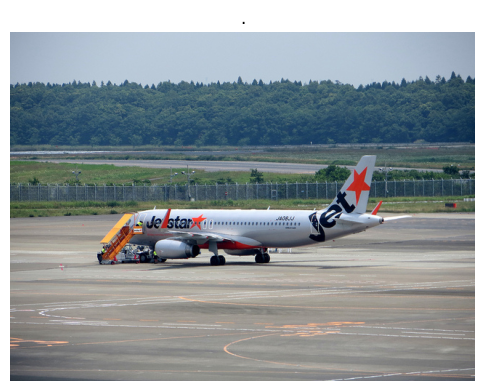

In [22]:
# Run beam search on one test image and display the result.
orig_image, image = next(iter(test_loader))
image = image.to(device)

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

with torch.no_grad():
    encoder_out = encoder(image)   # (1, 49, 2048)
    beam_ids = beam_search_caption(
        encoder_out       = encoder_out,
        decoder           = decoder,
        start_idx         = start_idx,
        end_idx           = end_idx,
        beam_size         = 5,
        max_len           = 20,
    )

beam_caption = (
    " ".join(vocab.idx2word[i] for i in beam_ids)
    .replace(" .", ".").replace(" ,", ",").strip()
)
print("Beam(5) Caption:", beam_caption)

plt.figure(figsize=(6, 6))
plt.imshow(np.squeeze(orig_image))
plt.axis("off")
plt.title(beam_caption)
plt.show()


Greedy : .
Beam(5): .


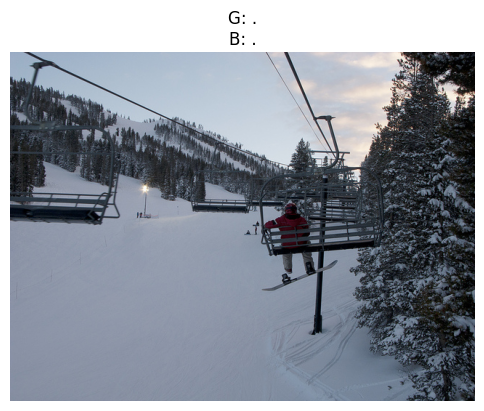

In [23]:
# Compare greedy and beam search side by side on one image.
# Beam search almost always produces a more fluent caption, especially on
# images with complex scenes where greedy commits to a suboptimal first word
# and then cannot recover.
orig_image, image = next(iter(test_loader))
image = image.to(device)

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

with torch.no_grad():
    encoder_out = encoder(image)

    greedy_ids = decoder.sample(encoder_out, start_idx, end_idx, max_len=20)
    greedy_caption = (
        " ".join(vocab.idx2word[i] for i in greedy_ids)
        .replace(" .", ".").replace(" ,", ",").strip()
    )

    beam_ids = beam_search_caption(encoder_out, decoder, start_idx, end_idx, beam_size=5, max_len=20)
    beam_caption = (
        " ".join(vocab.idx2word[i] for i in beam_ids)
        .replace(" .", ".").replace(" ,", ",").strip()
    )

print("Greedy :", greedy_caption)
print("Beam(5):", beam_caption)

plt.figure(figsize=(6, 6))
plt.imshow(np.squeeze(orig_image))
plt.axis("off")
plt.title(f"G: {greedy_caption}\nB: {beam_caption}")
plt.show()


In [24]:
# Sanity check the tensor shapes coming out of the loader and encoder.
# Useful if something downstream seems wrong — confirm the shapes are
# (1, 3, 224, 224) and (1, 49, 2048) before suspecting the model.
orig_image, image = next(iter(test_loader))
print("orig_image type/shape:", type(orig_image), getattr(orig_image, "shape", None))
print("image tensor shape   :", tuple(image.shape))   # should be (1, 3, 224, 224)

image = image.to(device)
with torch.no_grad():
    encoder_out = encoder(image)
print("encoder_out shape    :", tuple(encoder_out.shape))   # should be (1, 49, 2048)


orig_image type/shape: <class 'torch.Tensor'> torch.Size([1, 640, 515, 3])
image tensor shape   : (1, 3, 224, 224)
encoder_out shape    : (1, 49, 2048)


<a id='step3'></a>
## Step 3: Finish the Sampler

Before executing the next code cell, you must write the `sample` method in the `DecoderRNN` class in **model.py**.  This method should accept as input a PyTorch tensor `features` containing the embedded input features corresponding to a single image.

It should return as output a Python list `output`, indicating the predicted sentence.  `output[i]` is a nonnegative integer that identifies the predicted `i`-th token in the sentence.  The correspondence between integers and tokens can be explored by examining either `data_loader.dataset.vocab.word2idx` (or `data_loader.dataset.vocab.idx2word`).

After implementing the `sample` method, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.  Do **not** modify the code in the cell below.

In [25]:
def ids_to_caption(ids, vocab):
    # Convert a list of token ids to a readable caption string.
    #
    # An empty ids list means the model predicted <end> on the very first step
    # — the caption is literally nothing.  This almost always means the loaded
    # checkpoint is from a failed or very early training run.  We return a
    # visible diagnostic string rather than an empty string so the problem is
    # immediately obvious in the output.
    if not ids:
        return "[no caption — model predicted <end> on step 1; try a later checkpoint]"

    words = []
    for i in ids:
        word = vocab.idx2word.get(i, f"<unk:{i}>")
        # Drop any special tokens that leaked through — these should have been
        # filtered by sample() or beam_search(), but guard here just in case.
        if word in (vocab.start_word, vocab.end_word):
            continue
        words.append(word)

    if not words:
        return "[no caption — only special tokens were predicted]"

    caption = " ".join(words)
    # Clean up tokeniser artefacts: NLTK inserts spaces before punctuation.
    caption = caption.replace(" .", ".").replace(" ,", ",").replace(" '", "'")
    return caption.strip()


Caption: .


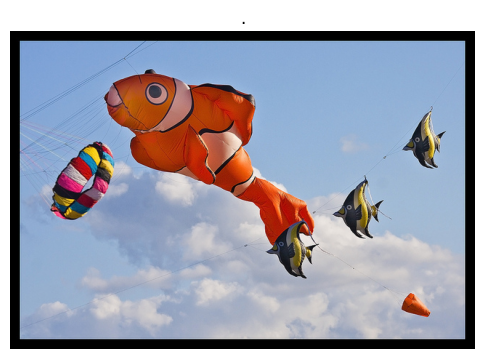

In [26]:
# Greedy caption on one test image using the ids_to_caption helper.
orig_image, image = next(iter(test_loader))
image = image.to(device)

start_idx = vocab.word2idx["<start>"]
end_idx   = vocab.word2idx["<end>"]

with torch.no_grad():
    encoder_out = encoder(image)
    output_ids  = decoder.sample(
        encoder_out = encoder_out,
        start_idx   = start_idx,
        end_idx     = end_idx,
        max_len     = 20,
    )

caption = ids_to_caption(output_ids, vocab)
print("Caption:", caption)

plt.figure(figsize=(6, 6))
plt.imshow(np.squeeze(orig_image))
plt.axis("off")
plt.title(caption)
plt.show()


<a id='step4'></a>
## Step 4: Clean up the Captions

In the code cell below, complete the `clean_sentence` function.  It should take a list of integers (corresponding to the variable `output` in **Step 3**) as input and return the corresponding predicted sentence (as a single Python string).

After completing the `clean_sentence` function above, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.

[1] .


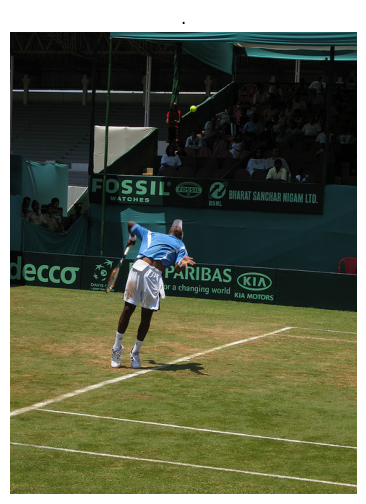

[2] .


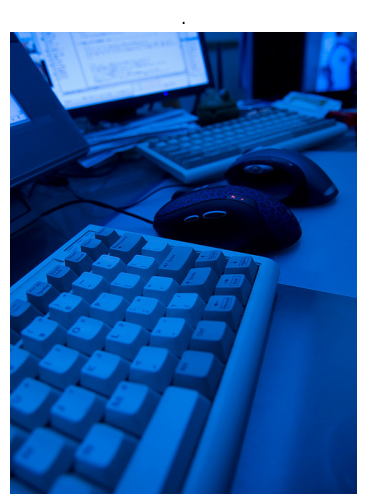

[3] .


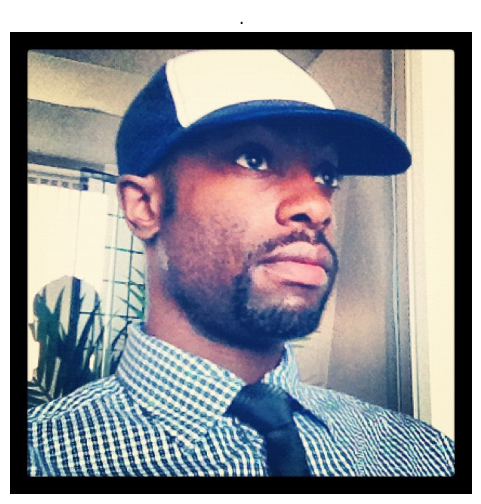

[4] .


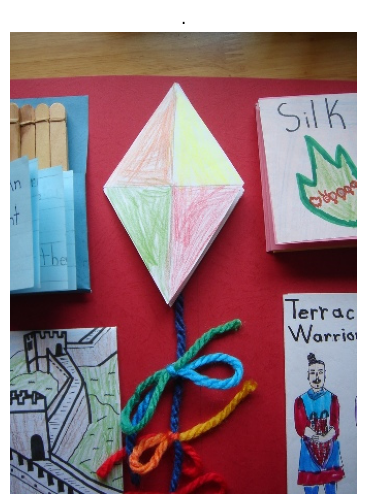

[5] .


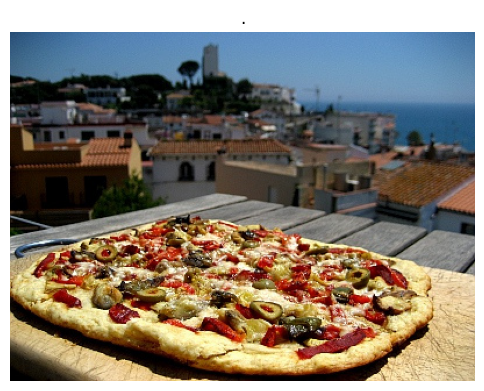

In [27]:
def show_n_predictions(loader, n=5, max_len=20):
    # Display captions for n consecutive test images.
    # Useful for a quick qualitative sense of how well the model is doing
    # before committing to a full evaluation run.
    encoder.eval()
    decoder.eval()
    start_idx = vocab.word2idx["<start>"]
    end_idx   = vocab.word2idx["<end>"]

    it = iter(loader)
    for i in range(n):
        orig_image, image = next(it)
        image = image.to(device)

        with torch.no_grad():
            encoder_out = encoder(image)
            ids         = decoder.sample(encoder_out, start_idx, end_idx, max_len=max_len)

        caption = ids_to_caption(ids, vocab)
        print(f"[{i+1}] {caption}")

        plt.figure(figsize=(6, 6))
        plt.imshow(np.squeeze(orig_image))
        plt.axis("off")
        plt.title(caption)
        plt.show()


show_n_predictions(test_loader, n=5, max_len=20)


In [28]:
import json


def dump_predictions(loader, out_json="/content/test2014_predictions.json", n=50, max_len=20):
    # Write greedy captions for n test images to a JSON file.
    # The file format is a list of {"caption": "..."} objects — compatible with
    # the COCO evaluation server if you also include an image_id field.
    encoder.eval()
    decoder.eval()
    start_idx = vocab.word2idx["<start>"]
    end_idx   = vocab.word2idx["<end>"]

    results = []
    it = iter(loader)

    for _ in range(n):
        orig_image, image = next(it)
        image = image.to(device)

        with torch.no_grad():
            encoder_out = encoder(image)
            ids         = decoder.sample(encoder_out, start_idx, end_idx, max_len=max_len)

        results.append({"caption": ids_to_caption(ids, vocab)})

    with open(out_json, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Wrote {len(results)} captions to {out_json}")


dump_predictions(test_loader, out_json="/content/test2014_predictions.json", n=50, max_len=20)


Wrote 50 captions to /content/test2014_predictions.json


<a id='step5'></a>
## Step 5: Generate Predictions!

In the code cell below, we have written a function (`get_prediction`) that you can use to use to loop over images in the test dataset and print your model's predicted caption.

Run the code cell below (multiple times, if you like!) to test how this function works.

As the last task in this project, you will loop over the images until you find four image-caption pairs of interest:
- Two should include image-caption pairs that show instances when the model performed well.
- Two should highlight image-caption pairs that highlight instances where the model did not perform well.

Use the four code cells below to complete this task.

### The model performed well!

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively accurate captions.

### The model could have performed better ...

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively inaccurate captions.